# Projet 6 - Classifier automatiquement des biens de consommation

## Ici nous allons utiliser d'autres algorithmes d'extraction, tel que CNN / Transfert Learning : VGG16 puis RestNet50

### Nous allons recuperer le dataset present dans le dossier /Source

In [ ]:
import os
import sys
import cv2
import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve, ConfusionMatrixDisplay, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from matplotlib.image import imread
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import resnet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalAveragePooling1D, Flatten, Dense, Dropout

import keras_core as keras
import keras_nlp

print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

In [2]:
sns.set(style="whitegrid")

In [3]:
dataset = pd.read_csv('../Source/dataset_for_cnn.csv')

In [4]:
img_path = "../Source/Flipkart/Images"

In [5]:
resultats_ari = []

### Chargement du backbone

In [6]:
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')
model = Model(inputs=vgg.inputs, outputs=vgg.layers[-2].output)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
def save_results(methode, ari, tableau):
    tableau.append({"Méthode": methode, "ARI": round(ari, 4)})
    return tableau

In [8]:
def features_retrieval_to_cluster(X_features, dataframe, methode="", n_comp_target=0.95, k_clusters=7):
    """
    Applique PCA + t-SNE + KMeans + ARI + Visualisation 2D sur une matrice de features.

    Args:
        X_features (np.ndarray or sparse matrix): Matrice [n_samples, n_features] issue d'une vectorisation texte.
        dataframe (pd.DataFrame): DataFrame d'origine contenant les catégories réelles.
        methode (str): Nom de la méthode (pour l'affichage).
    """
    print(f"Méthode : {methode}")

    # PCA complète pour visualiser la variance cunulee
    pca_full = PCA().fit(X_features)
    var_cum = np.cumsum(pca_full.explained_variance_ratio_)

    # Plot de la variance cumulée
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(var_cum) + 1), var_cum, marker='o')
    plt.axhline(y=n_comp_target, color='r', linestyle='--')
    plt.title(f'Variance cumulée expliquée - {methode}')
    plt.xlabel('Nombre de composantes principales')
    plt.ylabel('Variance cumulée expliquée')
    plt.tight_layout()
    plt.show()

    # Choix dynamique du n_components pour PCA
    n_comp = np.argmax(var_cum >= n_comp_target) + 1
    print(f"Nombre de composantes principales retenues : {n_comp}")
    print(f"→ {n_comp} composantes suffisent pour {n_comp_target*100:.1f}% de variance.")

    # Appliquer une PCA
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_features)

    print(f"Dimension après PCA : {X_pca.shape}")

    # Appliquer un t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_pca)
    dataframe["tsne_1"] = X_tsne[:, 0]
    dataframe["tsne_2"] = X_tsne[:, 1]

    print(f"Dimension après t-SNE : {X_tsne.shape}")


    # Appliquer KMeans
    kmeans = KMeans(n_clusters=k_clusters, random_state=42)
    dataframe["cluster"] = kmeans.fit_predict(X_pca)

    print(f"Clusters trouvés : {dataframe['cluster'].nunique()}")

    # Calucler l'ARI
    if "category_simple" not in dataframe:
        print("Aucune catégorie réelle pour le calcul de l'ARI.")
        dataframe["category_simple"] = dataframe["product_category_tree"].apply(lambda x: x.split(" >> ")[0].split('["')[1])
    ari = adjusted_rand_score(dataframe["category_simple"], dataframe["cluster"])
    print(f"Score ARI : {ari:.4f}")

    # Visualisation 2D
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=dataframe, x="tsne_1", y="tsne_2", hue="cluster", palette="tab10", alpha=0.7)
    plt.title(f"t-SNE projection + KMeans Clustering ({methode})")
    plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=dataframe, x="tsne_1", y="tsne_2", hue="category_simple", palette="tab10", alpha=0.7)
    plt.title(f"t-SNE projection + KMeans Clustering ({methode})")
    plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return ari

In [9]:
def load_img(name, folder=img_path, size=(224, 224), grey=False):
    """
    Load an image from the specified folder.
    
    Args:
        name (str): The name of the image file.
        folder (str): The folder where the image is located.
        
    Returns:
        np.ndarray: The loaded image as a numpy array.
    """
    p = os.path.join(folder, name)
    if not os.path.exists(p):
        print(f"Image {name} not found in {folder}.")
        return None
    img = cv2.imread(p)
    if grey:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)

In [10]:
def embed_vgg16(file_name, target_size=(224,224), dossier=img_path):
    """
    Transforme une image en un vecteur d'embedding VGG16.
    """
    img = load_img(file_name, folder=dossier, size=target_size, grey=False)
    if img is None:
        return np.zeros(512) # vecteur neutre
    
    x = preprocess_input(np.expand_dims(img, axis=0).astype(np.float32))
    return vgg.predict(x, verbose=0)[0]

In [11]:
def bovw_histograms(desc_list, k=300):
    """
    Transforme liste de descripteurs en matrice histo BoVW (n,k)
    """
    all_descriptors = np.vstack([d for d in desc_list if d is not None])
    bowv_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
    bowv_kmeans.fit(all_descriptors)

    def to_hist(d):
        """
        Transforme les descripteurs d'une image en histogramme BoVW
        """
        if d is None:
            return np.zeros(k)
        words = bowv_kmeans.predict(d)
        hist, _ = np.histogram(words, bins=np.arange(k + 1))
        return hist / hist.sum()
    return np.vstack([to_hist(d) for d in desc_list])

### On va venir boucler sur toutes les images et empiler les embedding

In [12]:
embeddings_vgg = []
for fname in tqdm.tqdm(dataset['image'].dropna().unique(), desc="Calcul des embeddings VGG16"):
    embedding = embed_vgg16(fname)
    embeddings_vgg.append(embedding)

X_vgg = np.vstack(embeddings_vgg)
print("Shape des embeddings VGG16 :", X_vgg.shape)

Calcul des embeddings VGG16: 100%|██████████| 1050/1050 [01:39<00:00, 10.57it/s]

Shape des embeddings VGG16 : (1050, 512)


Méthode : CNN-VGG16


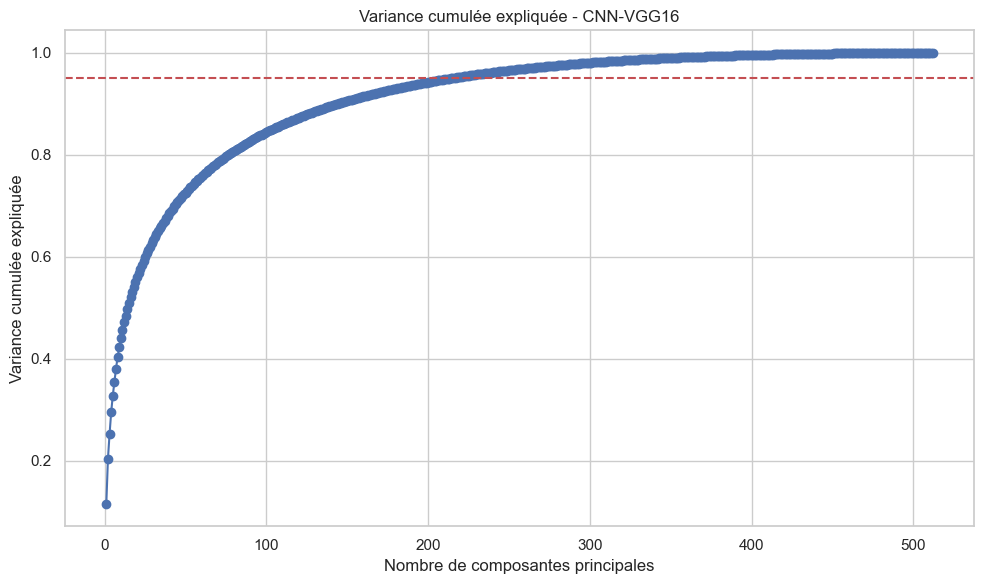

Nombre de composantes principales retenues : 214
→ 214 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 214)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.3079


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


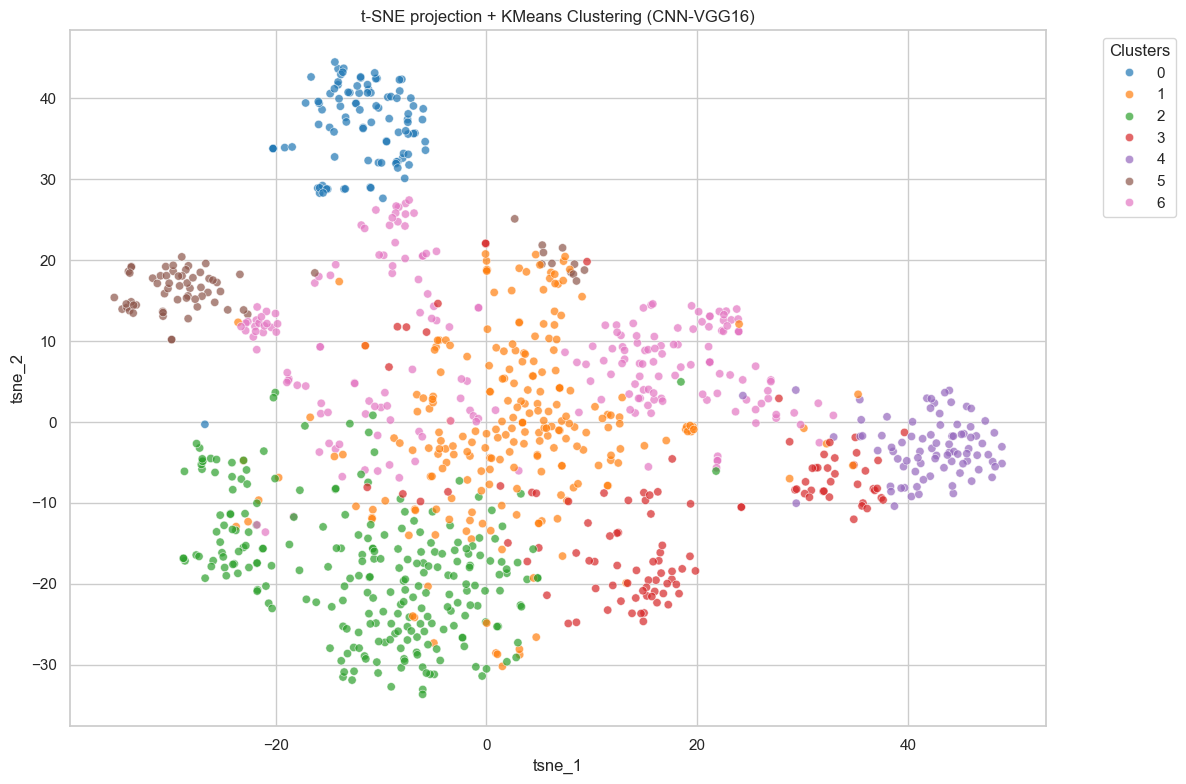

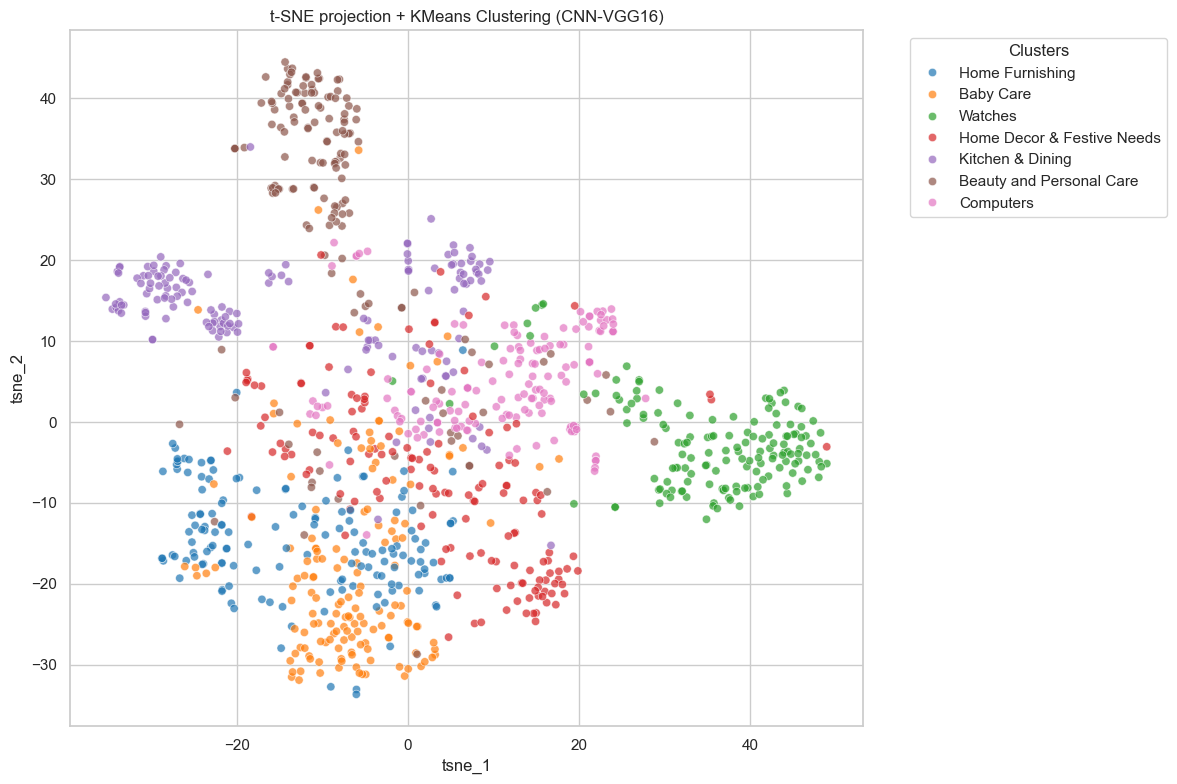

In [13]:
ari_vgg = features_retrieval_to_cluster(X_vgg, dataset.copy(), methode="CNN-VGG16")
resultats_ari = save_results("CNN-VGG16", ari_vgg, resultats_ari)

### Passons au ResNet50

In [14]:
resnet = resnet50.ResNet50(weights="imagenet", include_top=False, pooling="avg")

In [15]:
def embed_resnet50(file_name, target_size=(224,224), dossier=img_path):
    """
    Transforme une image en un vecteur d'embedding restnet50.
    """
    img = load_img(file_name, folder=dossier, size=target_size, grey=False)
    if img is None:
        return np.zeros(2048) # vecteur neutre
    
    x = preprocess_input(np.expand_dims(img, axis=0).astype(np.float32))
    return resnet.predict(x, verbose=0)[0]

In [16]:
embeddings_resnet50 = []
for fname in tqdm.tqdm(dataset['image'].dropna().unique(), desc="Calcul des embeddings resnet50"):
    embedding = embed_resnet50(fname)
    embeddings_resnet50.append(embedding)

X_resnet50 = np.vstack(embeddings_resnet50)
print("Shape des embeddings resnet50 :", X_resnet50.shape)

Calcul des embeddings resnet50: 100%|██████████| 1050/1050 [01:14<00:00, 14.16it/s]

Shape des embeddings resnet50 : (1050, 2048)


Méthode : CNN-ResNet50


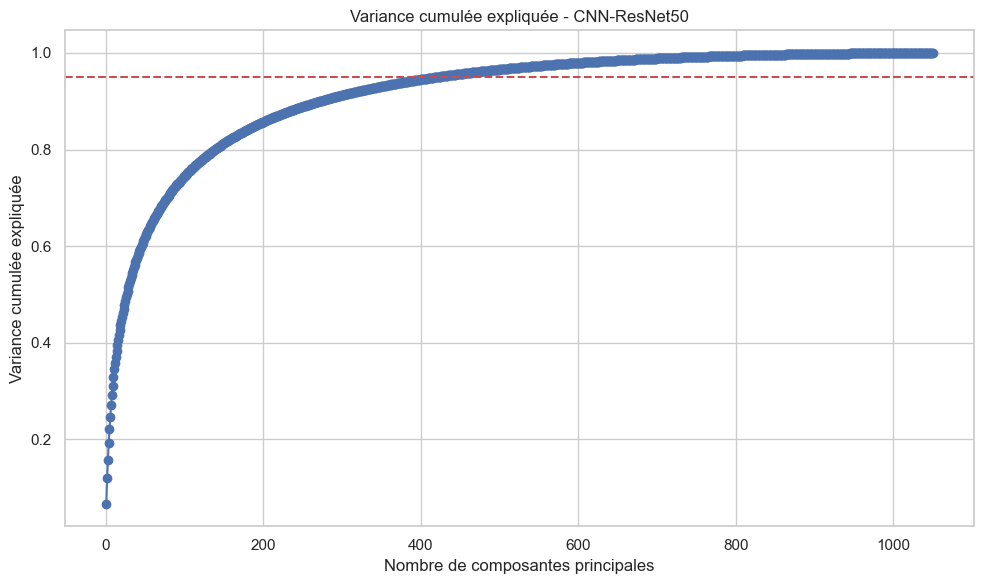

Nombre de composantes principales retenues : 421
→ 421 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 421)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.5074


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


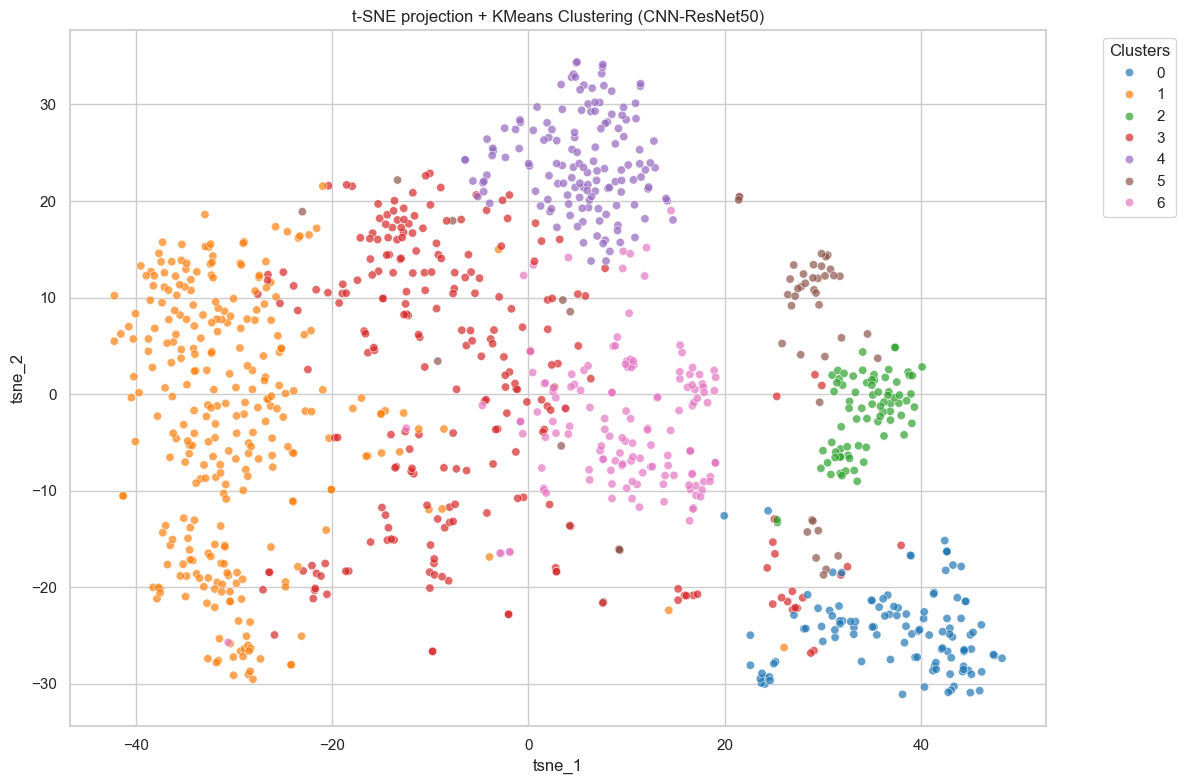

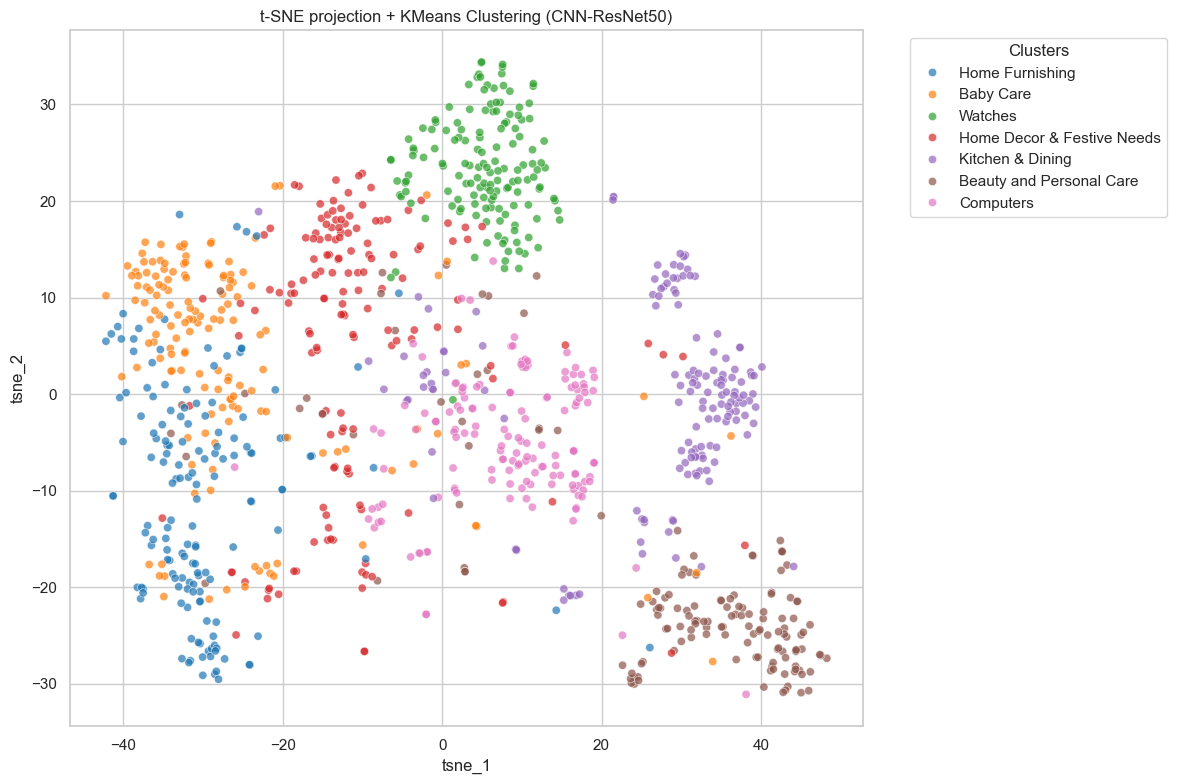

In [17]:
ari_resnet50 = features_retrieval_to_cluster(X_resnet50, dataset.copy(), methode="CNN-ResNet50")
resultats_ari = save_results("CNN-ResNet50", ari_resnet50, resultats_ari)

# Je vais maintenant rajouter une etape a l'etude de faisabillite : La transofrmation d'image

### Nous souhaitons effectuer les memes etapes que precedement mais en transformant nos images (niveaux de gris, reduction du bruit, contraste, etc..)

### Nous allons dans un premier temps creer une fonction permettant de retourner une copie transformee de l'image initial rgb

In [18]:
def preprocess_variant(img_rgb, mode="raw"):
    """
    Transforme une image RGB en une version modifiée selon la méthode spécifiée
    """
    if mode == "gris":
        return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    elif mode == "denoise":
        return cv2.medianBlur(img_rgb, 5)
    elif mode == "clahe":
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab = cv2.merge((clahe.apply(l), a, b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    elif mode == "sharpen":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(img_rgb, -1, kernel)
    return img_rgb  # mode "raw" ou non reconnu, retourne l'image originale


### Testons notre fonction de transformation

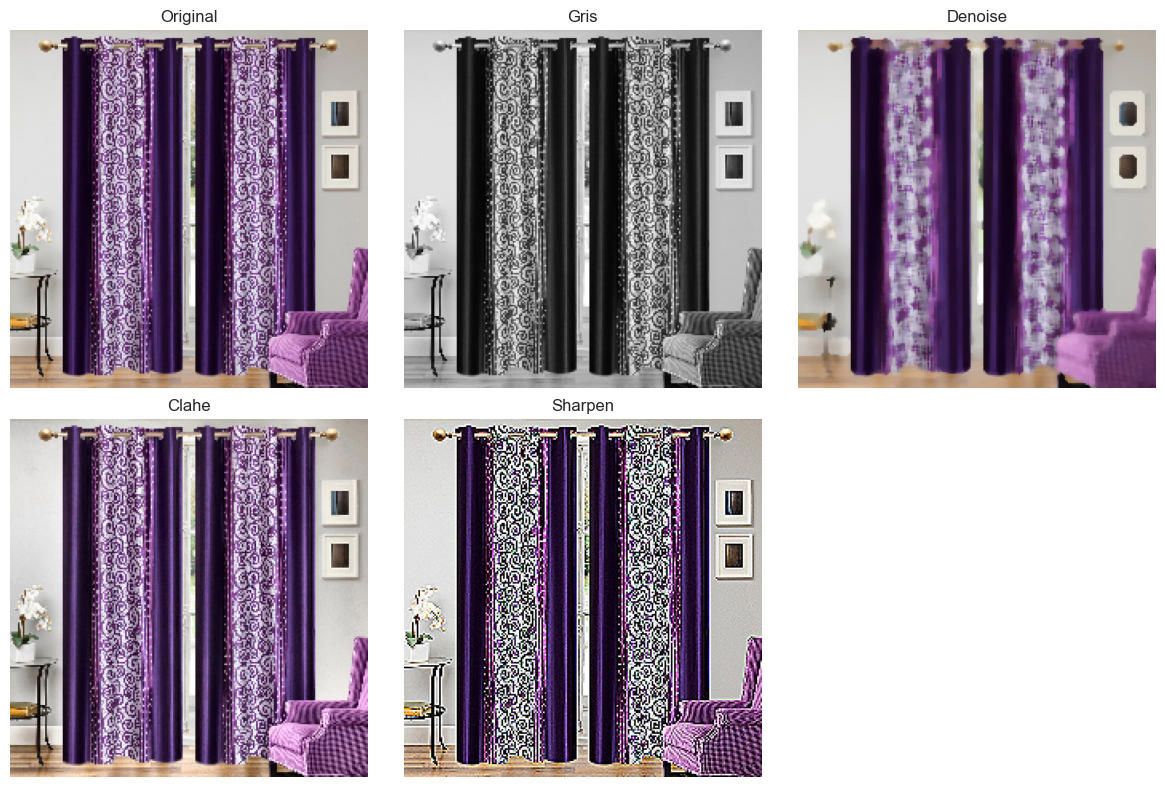

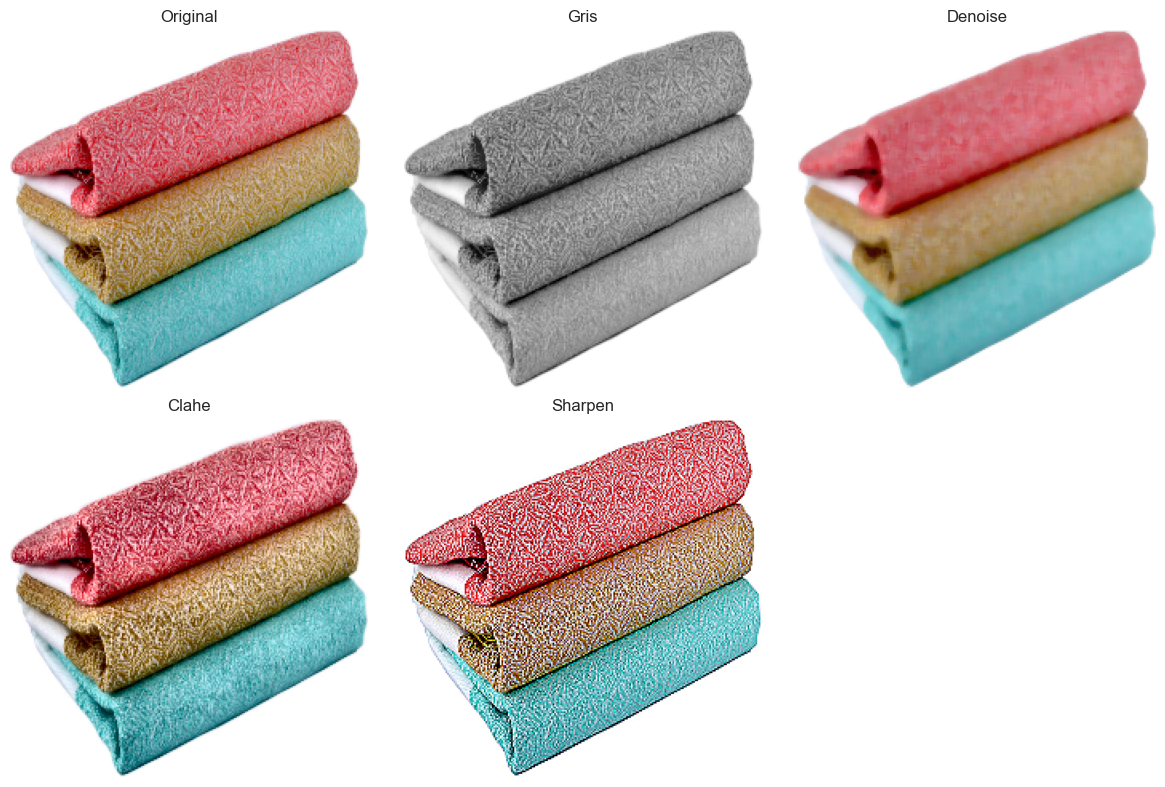

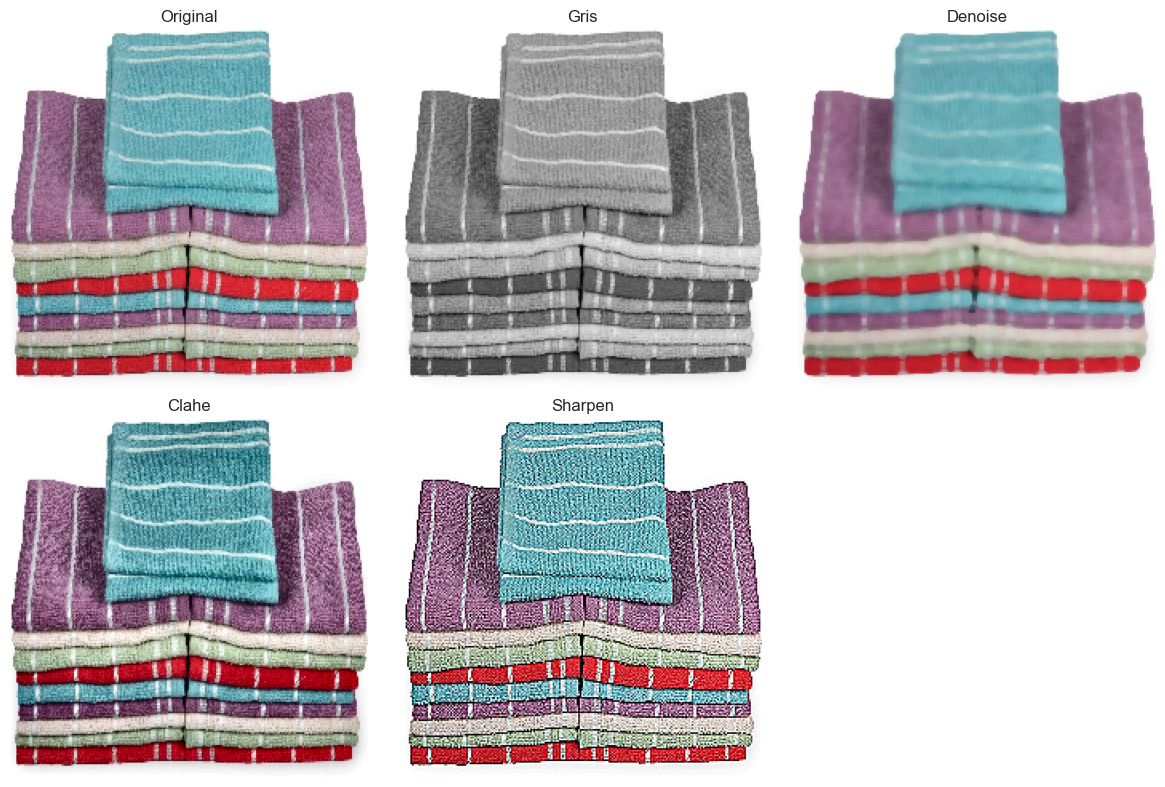

In [19]:
for name in dataset['image'].dropna().unique()[:3]:
    img = load_img(name)
    if img is not None:
        plt.figure(figsize=(12, 8))
        plt.subplot(2, 3, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        modes = ["gris", "denoise", "clahe", "sharpen"]
        for i, mode in enumerate(modes):
            img_variant = preprocess_variant(img, mode=mode)
            plt.subplot(2, 3, i + 2)
            plt.imshow(img_variant, cmap='gray' if mode == "gris" else None)
            plt.title(mode.capitalize())
            plt.axis('off')

        plt.tight_layout()
        plt.show()

### Tres bien nous avons bien nos differentes transformations

## A present appliquons ces transformations en prenons en compte les etapes precedentes

In [20]:
def get_orb_descriptors(mode="raw"):
    """
    Renvoie la liste des descripteurs ORB pour chaque image transformée
    """
    orb = cv2.ORB_create(nfeatures=500)
    descriptors_list = []
    
    for name in tqdm.tqdm(dataset['image'].dropna().unique(), desc=f"Calcul des descripteurs ORB ({mode})"):
        img = load_img(name, img_path, grey=False)
        if img is None:
            descriptors_list.append(None)
            continue
        img_variant = preprocess_variant(img, mode=mode)
        # Si l'image est en couleur, la convertir en niveaux de gris
        if len(img_variant) == 3:
            img_variant = cv2.cvtColor(img_variant, cv2.COLOR_RGB2GRAY)
        # Calculer les descripteurs ORB
        keypoints, descriptors = orb.detectAndCompute(img_variant, None)
        descriptors_list.append(descriptors)
    
    return descriptors_list

In [21]:
def bovw_histograms(desc_list, k=300):
    """
    Transforme liste de descripteurs en matrice histo BoVW (n,k)
    """
    all_descriptors = np.vstack([d for d in desc_list if d is not None])
    bowv_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
    bowv_kmeans.fit(all_descriptors)

    def to_hist(d):
        """
        Transforme les descripteurs d'une image en histogramme BoVW
        """
        if d is None:
            return np.zeros(k)
        words = bowv_kmeans.predict(d)
        hist, _ = np.histogram(words, bins=np.arange(k + 1))
        return hist / hist.sum()
    return np.vstack([to_hist(d) for d in desc_list])

In [22]:
def resnet_embeddings(mode="raw"):
    """
    Renvoie les embeddings ResNet pour chaque image transformée
    """
    resnet = resnet50.ResNet50(weights="imagenet", include_top=False, pooling="avg")
    embeddings = []
    
    for name in tqdm.tqdm(dataset['image'].dropna().unique(), desc=f"Calcul des embeddings ResNet ({mode})"):
        img = load_img(name, img_path)
        if img is None:
            embeddings.append(np.zeros(2048))  # vecteur neutre
            continue
        img_variant = preprocess_variant(img, mode=mode)
        x = preprocess_input(np.expand_dims(img_variant, axis=0).astype(np.float32))
        embeddings.append(resnet.predict(x, verbose=0)[0])
    
    return np.vstack(embeddings)

## Mettons en place notre boucle d'experimentation

Calcul des descripteurs ORB (gris): 100%|██████████| 1050/1050 [00:08<00:00, 126.00it/s]
c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Méthode : ORB-BoVW-gris


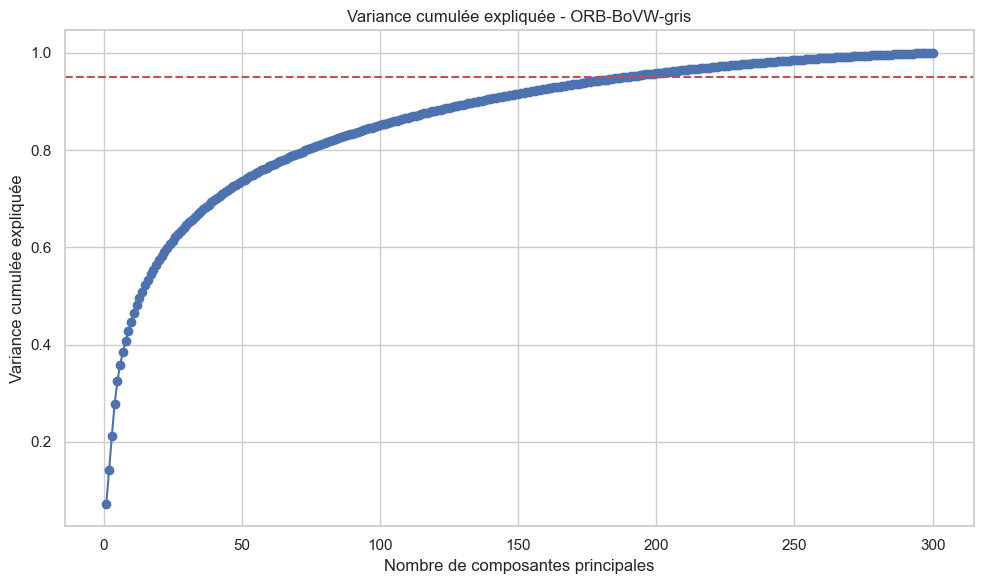

Nombre de composantes principales retenues : 189
→ 189 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 189)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.0211


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


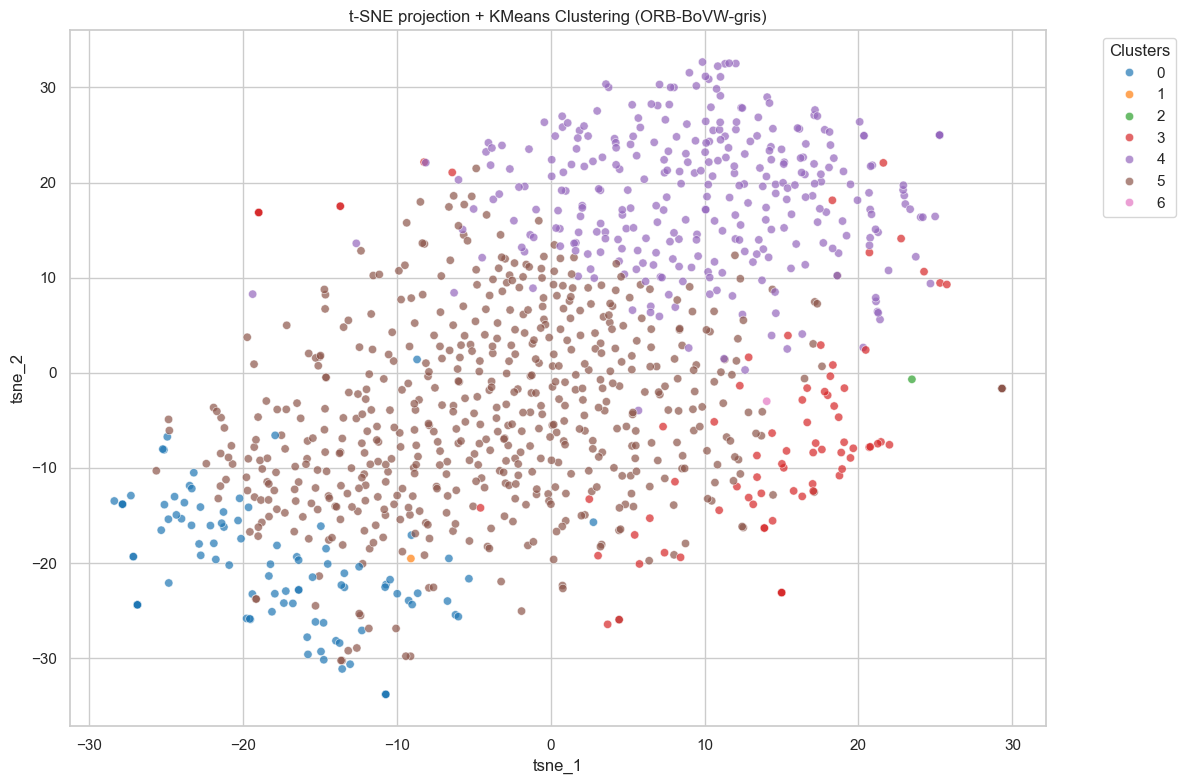

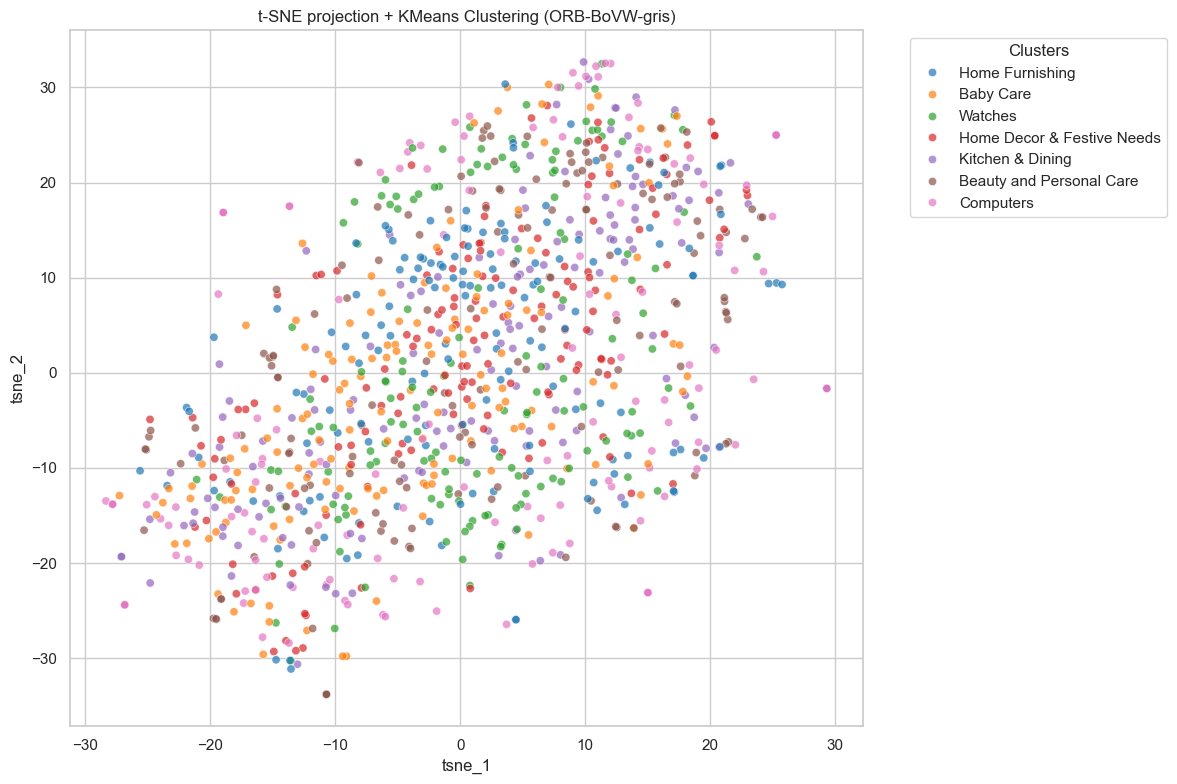

Calcul des descripteurs ORB (denoise): 100%|██████████| 1050/1050 [00:08<00:00, 123.72it/s]
c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Méthode : ORB-BoVW-denoise


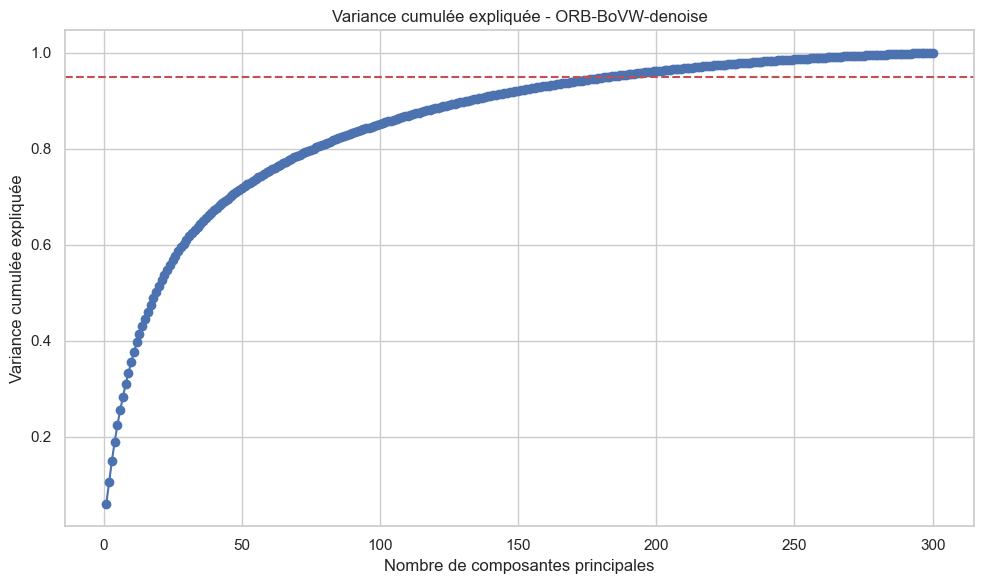

Nombre de composantes principales retenues : 183
→ 183 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 183)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.0080


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


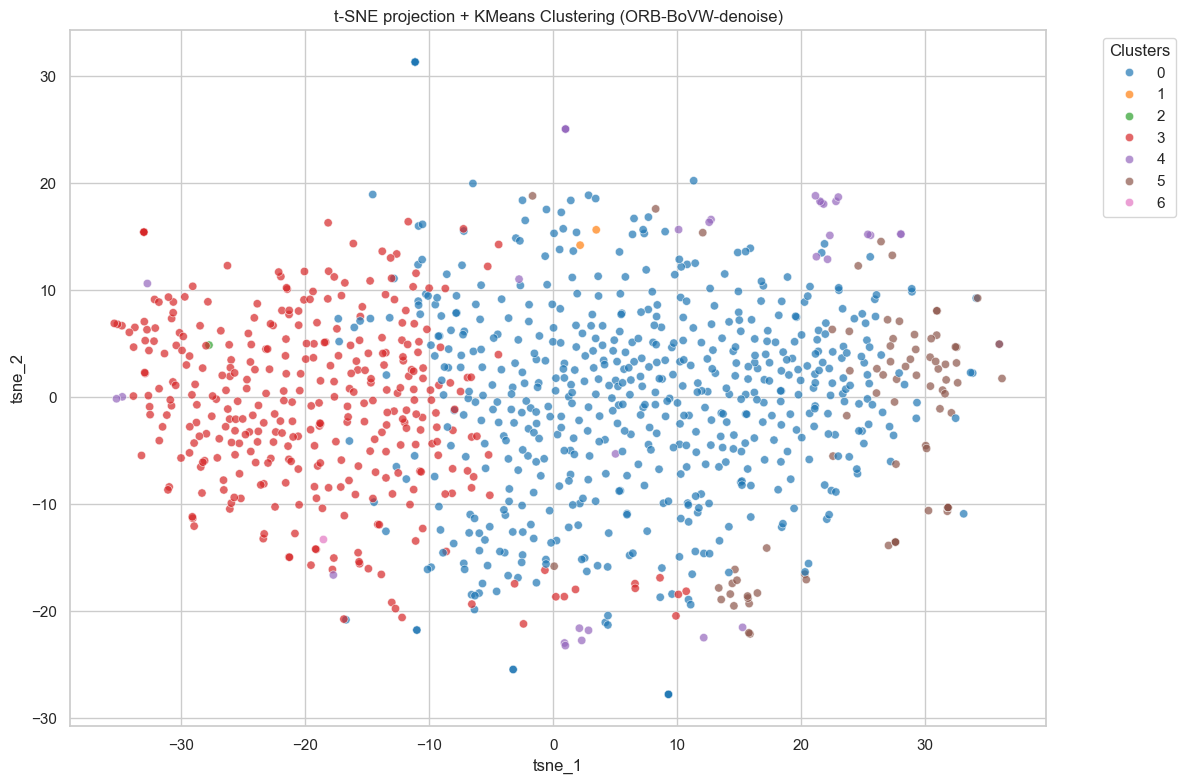

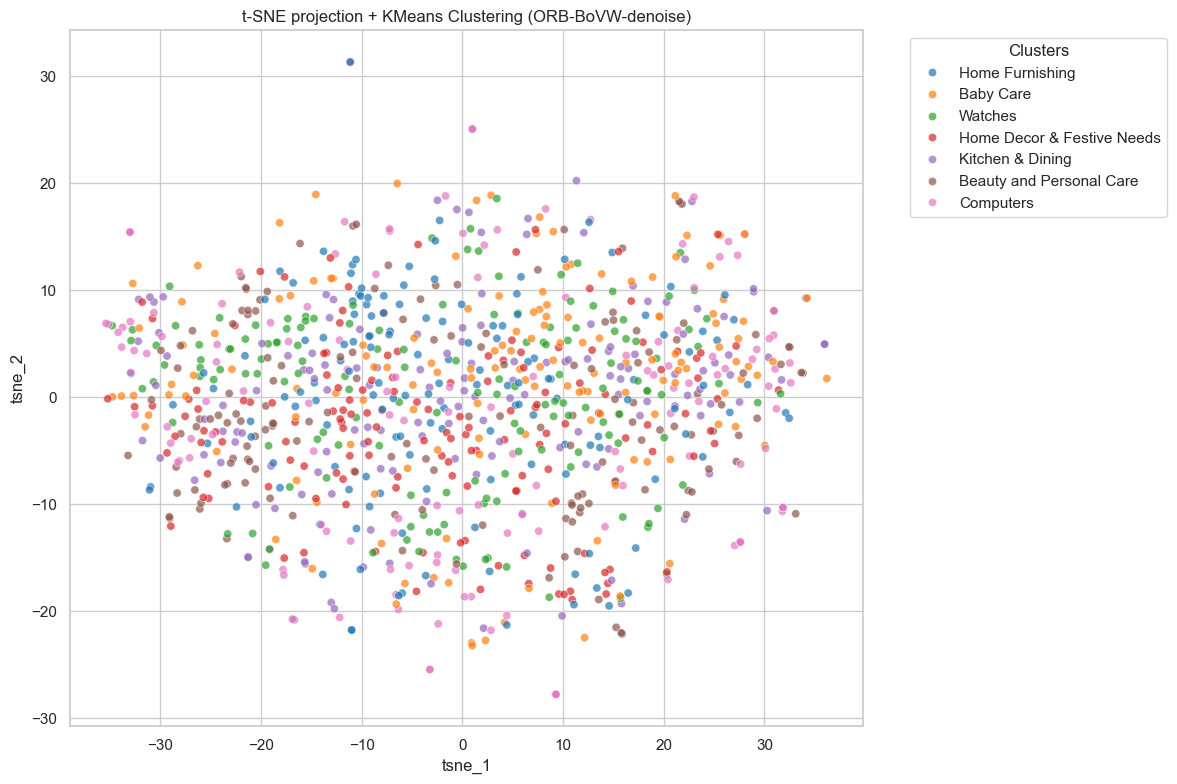

Calcul des descripteurs ORB (sharpen): 100%|██████████| 1050/1050 [00:08<00:00, 126.30it/s]
c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Méthode : ORB-BoVW-sharpen


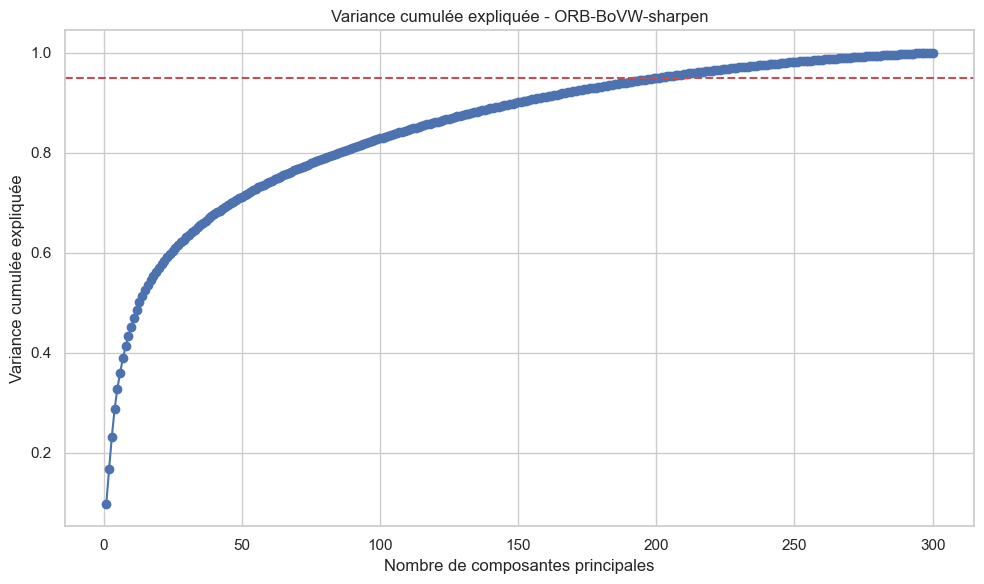

Nombre de composantes principales retenues : 201
→ 201 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 201)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.0172


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


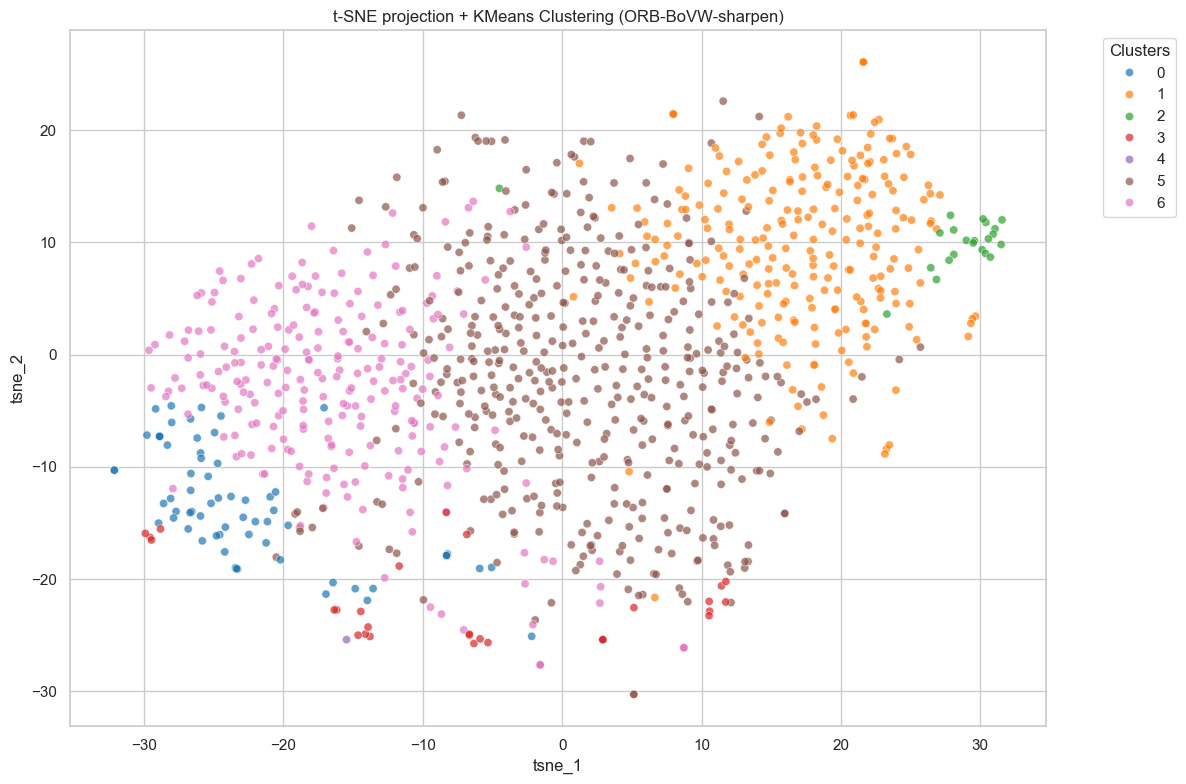

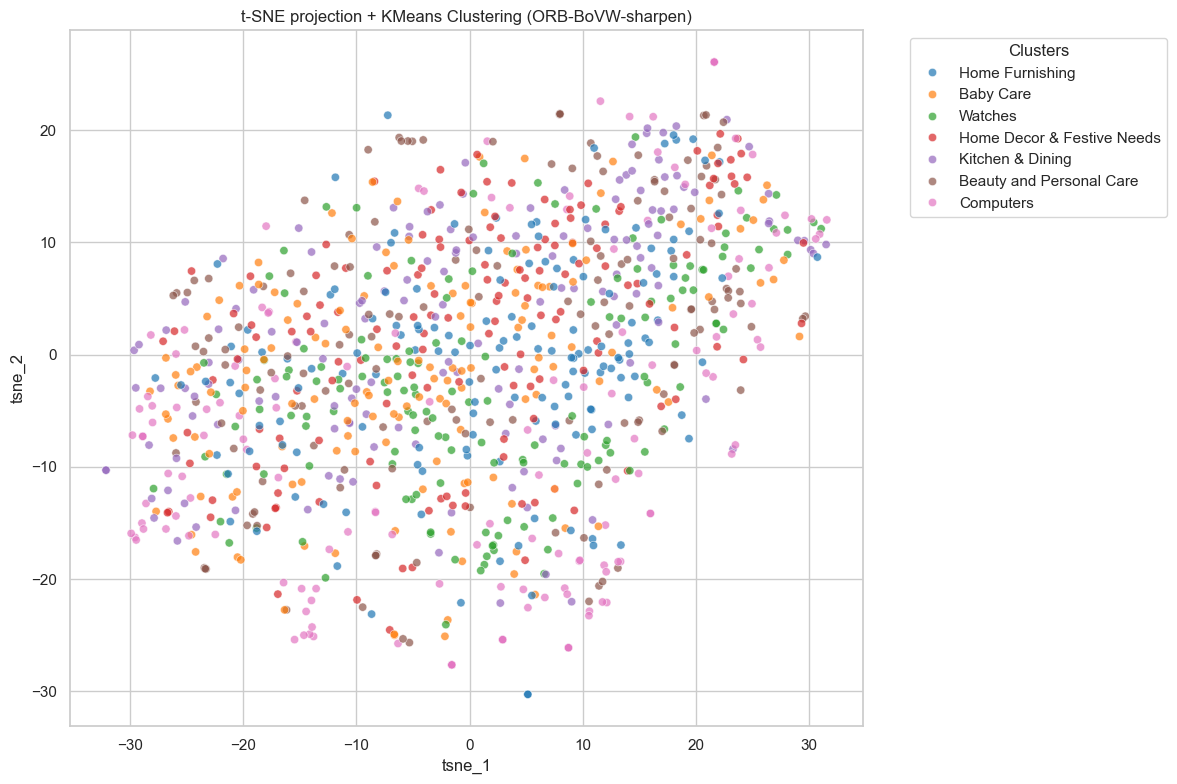

Calcul des embeddings ResNet (clahe): 100%|██████████| 1050/1050 [01:15<00:00, 13.85it/s]


Méthode : CNN-ResNet50-clahe


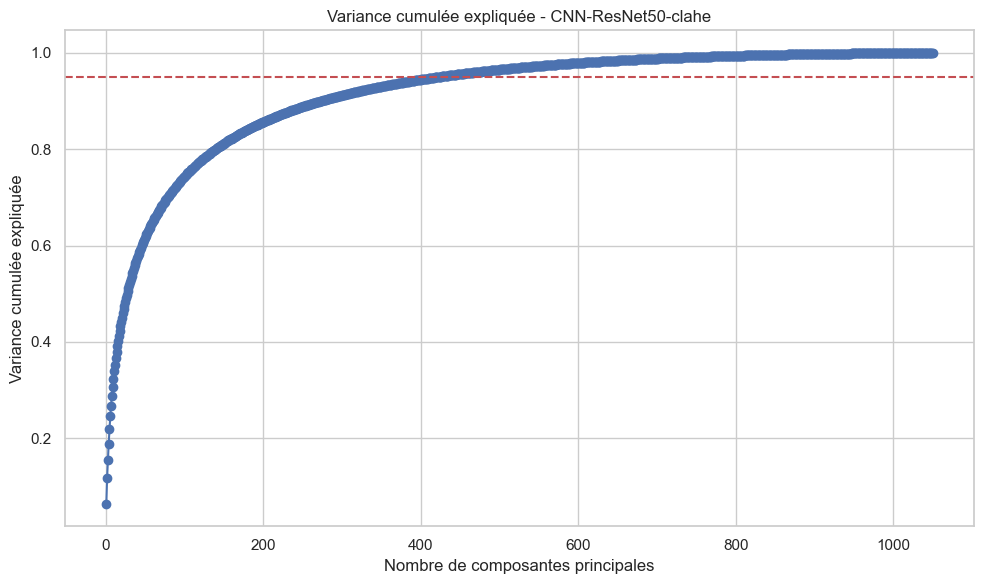

Nombre de composantes principales retenues : 422
→ 422 composantes suffisent pour 95.0% de variance.
Dimension après PCA : (1050, 422)
Dimension après t-SNE : (1050, 2)
Clusters trouvés : 7
Score ARI : 0.4227


c:\Users\cosic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


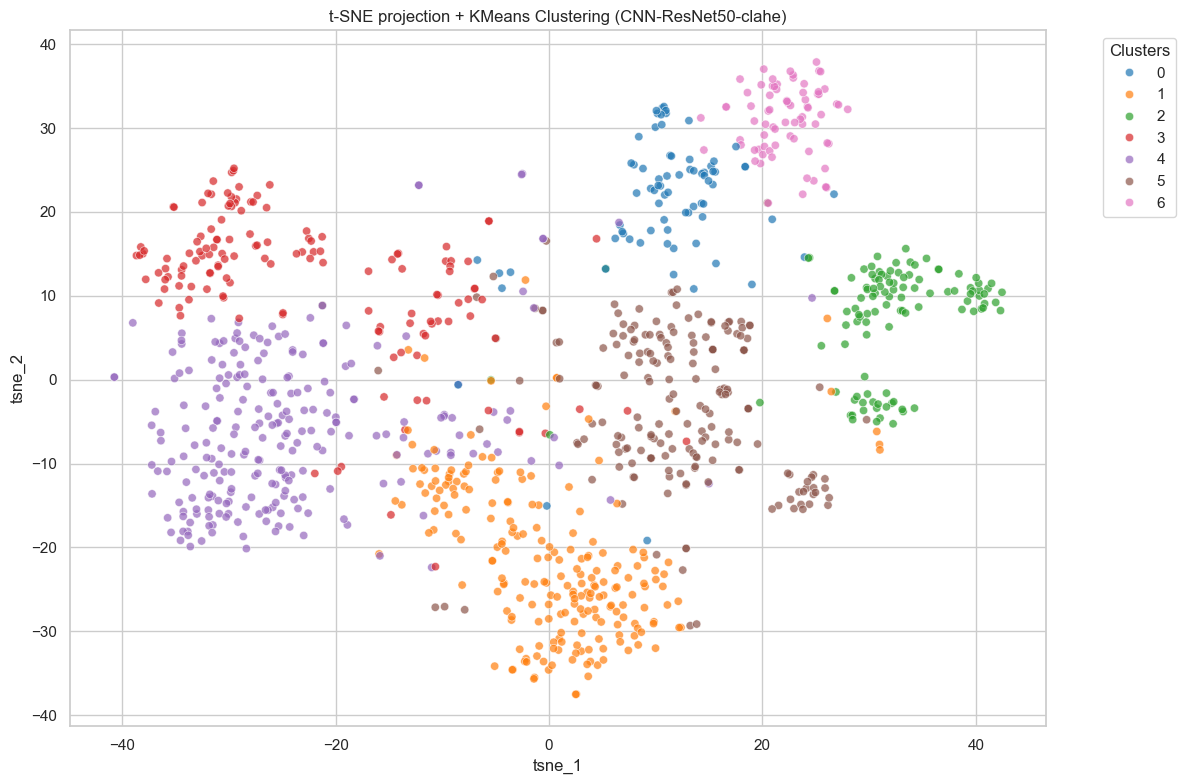

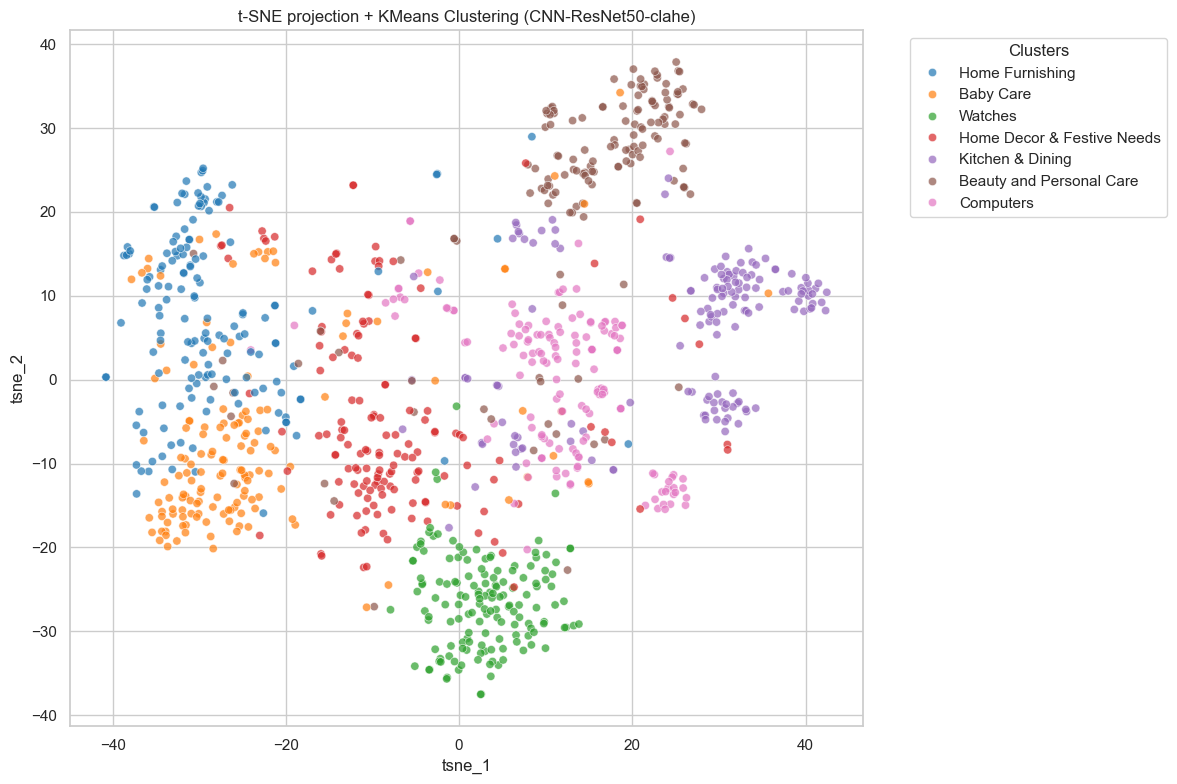

In [23]:
VARIANTS_ORB  = ["gris", "denoise", "sharpen"]
VARIANTS_CNN  = ["clahe"]

# ORB / BoVW pour chaque variante
for mode in VARIANTS_ORB:
    descs = get_orb_descriptors(mode=mode)
    X_bovw = bovw_histograms(descs, k=300)
    ari = features_retrieval_to_cluster(X_bovw, dataset.copy(), methode=f"ORB-BoVW-{mode}")
    resultats_ari = save_results(f"ORB-BoVW-{mode}", ari, resultats_ari)

# ResNet50 pour chaque variante
for mode in VARIANTS_CNN:
    X_resnet = resnet_embeddings(mode=mode)
    ari = features_retrieval_to_cluster(X_resnet, dataset.copy(), methode=f"CNN-ResNet50-{mode}")
    resultats_ari = save_results(f"CNN-ResNet50-{mode}", ari, resultats_ari)

In [24]:
resultats_ari

[{'Méthode': 'CNN-VGG16', 'ARI': 0.3079},
 {'Méthode': 'CNN-ResNet50', 'ARI': 0.5074},
 {'Méthode': 'ORB-BoVW-gris', 'ARI': 0.0211},
 {'Méthode': 'ORB-BoVW-denoise', 'ARI': 0.008},
 {'Méthode': 'ORB-BoVW-sharpen', 'ARI': 0.0172},
 {'Méthode': 'CNN-ResNet50-clahe', 'ARI': 0.4227}]

# Affichons tout ceci dans un tableau + bar plot

In [25]:
df_res = pd.DataFrame(resultats_ari).sort_values("ARI", ascending=False)
print(df_res)

              Méthode     ARI
1        CNN-ResNet50  0.5074
5  CNN-ResNet50-clahe  0.4227
0           CNN-VGG16  0.3079
2       ORB-BoVW-gris  0.0211
4    ORB-BoVW-sharpen  0.0172
3    ORB-BoVW-denoise  0.0080


C:\Users\cosic\AppData\Local\Temp\ipykernel_28856\1344167723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x="ARI", y="Méthode", palette="viridis")


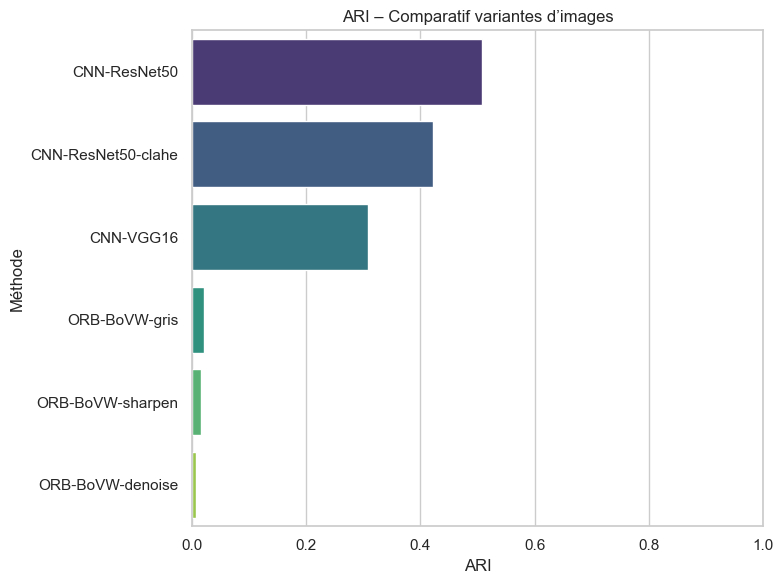

In [26]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_res, x="ARI", y="Méthode", palette="viridis")
plt.title("ARI – Comparatif variantes d’images")
plt.xlim(0, 1); plt.tight_layout(); plt.show()

### Ce que nous pouvons rapidement constater :
- #### Aucune transformation simple (CLAHE, gris, denoise, sharpen) ne dépasse la version brute
- #### Le CNN pré-entraîné reste nettement au-dessus de toutes les variantes ORB. Les améliorations possibles se joueront plutôt sur le nombre de clusters ou du fine-tuning

# Classification supervisee - Data Augmentation

### L'objectif sera de predire la 'categorie_simple' a partir de la photo d'un produit. La demarche sera faite sur 2 backbones, VGG16 puis ResNet-50

In [27]:
# Creation de la colonne de catégorie simple
dataset["category_simple"] = dataset["product_category_tree"].apply(lambda x: x.split(" >> ")[0].split('["')[1])

### Creation d'une fonction pour visualiser l'accuracy / loss (train vs validation) une fois notre entrainement termine

In [28]:
def plot_training_curves(hist, title="ResNet-50 – data augmentation"):
    """
    Affiche accuracy & loss pour l'entrainement Keras
    """
    acc = hist.history["accuracy"]
    val_acc = hist.history["val_accuracy"]
    loss = hist.history["loss"]
    val_loss = hist.history["val_loss"]
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, "b-o", label="Train")
    plt.plot(epochs, val_acc, "r-o", label="Val")
    plt.title(f"Accuracy – {title}")
    plt.xlabel("Époques"); plt.ylabel("Accuracy"); plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, "b-o", label="Train")
    plt.plot(epochs, val_loss, "r-o", label="Val")
    plt.title(f"Loss – {title}")
    plt.xlabel("Époques"); plt.ylabel("Loss"); plt.legend()

    plt.tight_layout(); plt.show()

### Ici nous allons creer notre data generator decoupe en 80/20 train/valid

In [32]:
IMG_SIZE = (224, 224)

train_aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input)

train_gen = train_aug.flow_from_dataframe(
    dataframe=dataset,
    x_col='image',
    y_col='category_simple',
    directory=img_path,
    target_size=IMG_SIZE,
    class_mode='categorical',
    subset='training',
    batch_size=32)

valid_gen = train_aug.flow_from_dataframe(
    dataframe=dataset,
    x_col='image',
    y_col='category_simple',
    directory=img_path,
    target_size=IMG_SIZE,
    class_mode='categorical',
    subset='validation',
    batch_size=32)

Found 840 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


## Backbone VGG16

In [33]:
base = VGG16(weights="imagenet",
             include_top=False,
             input_shape=IMG_SIZE + (3,),
             pooling="avg")

base.trainable = False

In [34]:
model = models.Sequential([
    base,
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,935 (57.15 MB)

 Trainable params: 266,247 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [37]:
history_vgg16 = model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen
)

c:\Users\cosic\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
14/27 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2631 - loss: 6.9352

c:\Users\cosic\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.3788 - loss: 5.5251 - val_accuracy: 0.6238 - val_loss: 2.2198
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7963 - loss: 1.1929 - val_accuracy: 0.6286 - val_loss: 1.7648
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8322 - loss: 0.8321 - val_accuracy: 0.6429 - val_loss: 1.5963
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8781 - loss: 0.5648 - val_accuracy: 0.7524 - val_loss: 1.1129
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8783 - loss: 0.3972 - val_accuracy: 0.6571 - val_loss: 1.4554
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9073 - loss: 0.2479 - val_accuracy: 0.6952 - val_loss: 1.1874
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9323 - loss: 0.2328 - val_accuracy: 0.7286 - val_loss: 1.1406
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9421 - loss: 0.1747 - val_accuracy: 0.7190 - val_loss: 1.2828
Epo

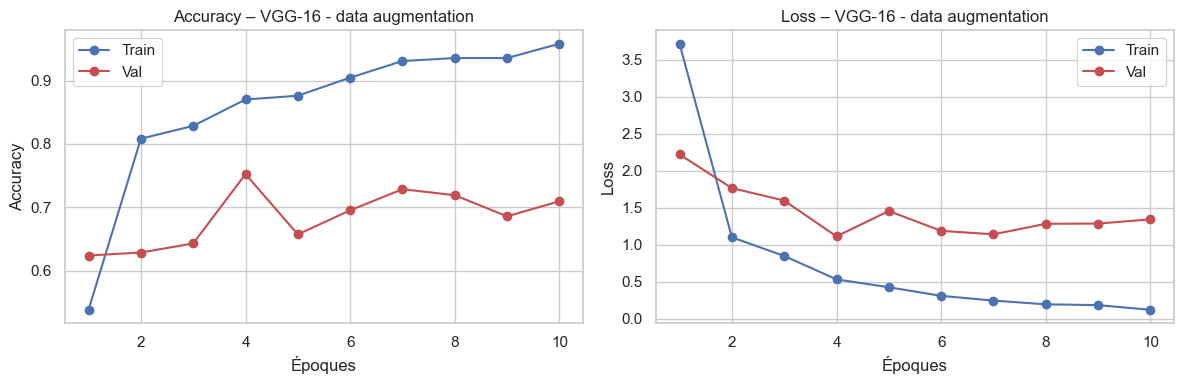

In [38]:
plot_training_curves(history_vgg16, title="VGG-16 - data augmentation")

In [39]:
model2 = models.Sequential([
    base,
    layers.Dense(1024, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [41]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,247,175 (58.16 MB)

 Trainable params: 532,487 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [42]:
history_vgg16 = model2.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4338 - loss: 5.1777 - val_accuracy: 0.7190 - val_loss: 2.1698
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8004 - loss: 1.4203 - val_accuracy: 0.6333 - val_loss: 2.5424
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8597 - loss: 0.6965 - val_accuracy: 0.6667 - val_loss: 2.1222
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8644 - loss: 0.4691 - val_accuracy: 0.7048 - val_loss: 1.8330
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9141 - loss: 0.2825 - val_accuracy: 0.6810 - val_loss: 1.8555
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9466 - loss: 0.2104 - val_accuracy: 0.7000 - val_loss: 1.5874
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9309 - loss: 0.2750 - val_accuracy: 0.6762 - val_loss: 1.7810
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9655 - loss: 0.1129 - val_accuracy: 0.7381 - val_loss:

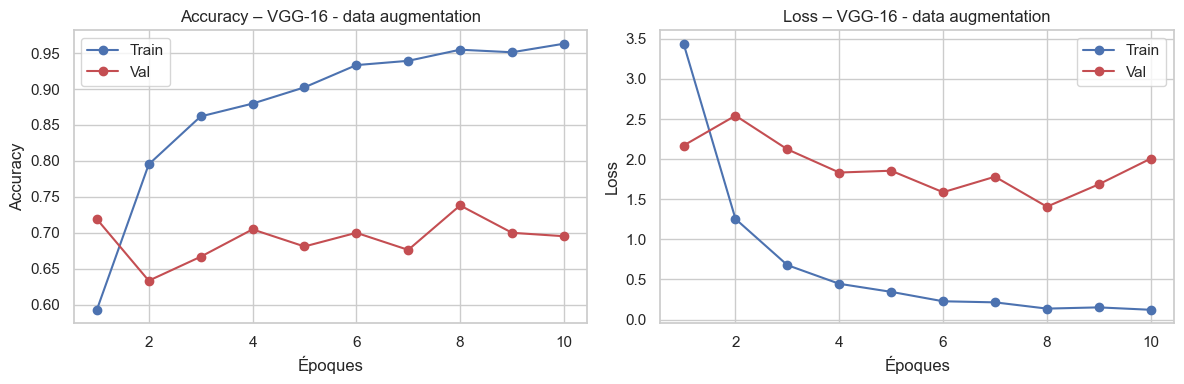

In [43]:
plot_training_curves(history_vgg16, title="VGG-16 - data augmentation")

## 🔬 Comparaison des architectures (VGG16 + Dense)

Nous avons testé deux architectures avec VGG16 en base :

- **model** : 1 couche Dense de **512** neurones (`Dense(512, activation="relu")`)
- **model2** : 1 couche Dense de **1024** neurones (`Dense(1024, activation="relu")`)
- Dans les deux cas, une couche **Dropout(0.5)** a été utilisée pour limiter le surapprentissage.

### 📈 Résultats observés (courbes accuracy et loss)

| Critère                        | `model` (512 neurones)                             | `model2` (1024 neurones)                           |
|-------------------------------|----------------------------------------------------|----------------------------------------------------|
| **Accuracy validation**       | Stable autour de 72–74%                            | Similaire (70–73%), mais plus instable             |
| **Loss validation**           | Commence à augmenter après l’epoch 5               | Hausse plus nette et précoce                       |
| **Surapprentissage**          | Léger, mais raisonnable                            | Plus prononcé (écart train/val plus fort)          |

### ✅ Conclusion

- `model` offre **de meilleures performances de généralisation** avec un risque de surapprentissage plus faible.
- `model2` est plus puissant, mais **n'apporte pas de gain sur la validation** dans notre cas.
- **Recommandation :** garder `model` avec `Dense(512)` et éventuellement tester une architecture plus compacte ou avec plus de régularisation (Dropout ou BatchNorm)



## Backbone ResNet50

In [44]:
train_aug = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True,
        validation_split=0.2,
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

train_gen = train_aug.flow_from_dataframe(
        dataframe=dataset,
        x_col='image',
        y_col='category_simple',
        directory=img_path,
        target_size=IMG_SIZE,
        class_mode='categorical',
        subset='training',
        batch_size=32)

val_gen = train_aug.flow_from_dataframe(
        dataframe=dataset,
        x_col='image',
        y_col='category_simple',
        directory=img_path,
        target_size=IMG_SIZE,
        class_mode='categorical',
        subset='validation',
        batch_size=32)

Found 840 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


In [45]:
base = tf.keras.applications.ResNet50(weights='imagenet',
                                      include_top=False,
                                      input_shape=IMG_SIZE+(3,),
                                      pooling='avg')

base.trainable = False

In [46]:
model3 = models.Sequential([
    base,
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,640,391 (94.00 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [48]:
history_resnet50 = model3.fit(
    train_gen, 
    epochs=10, 
    validation_data=valid_gen)

c:\Users\cosic\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 7/27 ━━━━━━━━━━━━━━━━━━━━ 15s 782ms/step - accuracy: 0.2790 - loss: 2.6601

c:\Users\cosic\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.4924 - loss: 1.8519 - val_accuracy: 0.6810 - val_loss: 0.9319
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8222 - loss: 0.5491 - val_accuracy: 0.7095 - val_loss: 0.8620
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8816 - loss: 0.3773 - val_accuracy: 0.7476 - val_loss: 0.8040
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9161 - loss: 0.2265 - val_accuracy: 0.8381 - val_loss: 0.5664
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9252 - loss: 0.2153 - val_accuracy: 0.7714 - val_loss: 0.6966
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9630 - loss: 0.1235 - val_accuracy: 0.7619 - val_loss: 0.7239
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9707 - loss: 0.0893 - val_accuracy: 0.7667 - val_loss: 0.7752
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9734 - loss: 0.0835 - val_accuracy: 0.7571 - val_loss: 0.8143
Epo

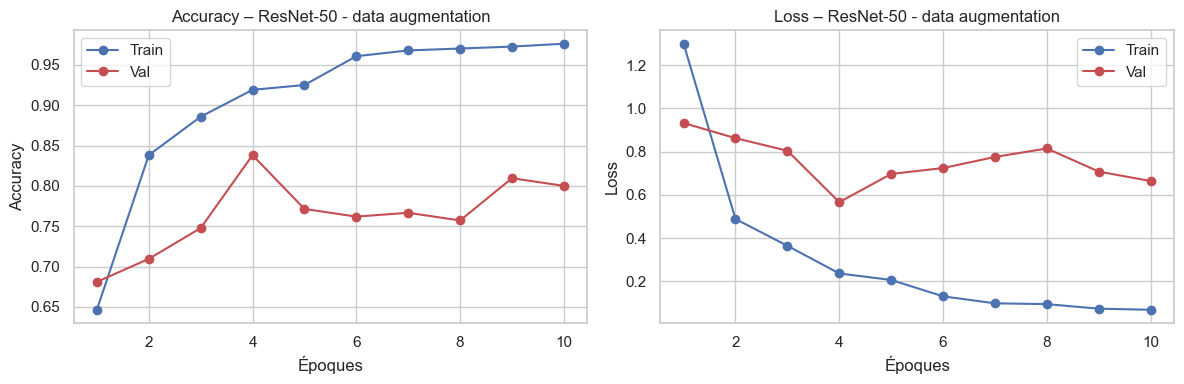

In [49]:
plot_training_curves(history_resnet50, title="ResNet-50 - data augmentation")

In [50]:
model4 = models.Sequential([
    base,
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])

model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [51]:
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,693,063 (98.01 MB)

 Trainable params: 2,105,351 (8.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [52]:
history_resnet50 = model4.fit(
    train_gen, 
    epochs=10, 
    validation_data=valid_gen)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5290 - loss: 1.7274 - val_accuracy: 0.6524 - val_loss: 1.2046
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8491 - loss: 0.6036 - val_accuracy: 0.6286 - val_loss: 1.5169
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8657 - loss: 0.4128 - val_accuracy: 0.7095 - val_loss: 0.9464
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9158 - loss: 0.2632 - val_accuracy: 0.8286 - val_loss: 0.6194
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9632 - loss: 0.1228 - val_accuracy: 0.7619 - val_loss: 0.7768
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9565 - loss: 0.1100 - val_accuracy: 0.7952 - val_loss: 0.7782
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9676 - loss: 0.1091 - val_accuracy: 0.8238 - val_loss: 0.7082
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9849 - loss: 0.0522 - val_accuracy: 0.6286 - val_loss:

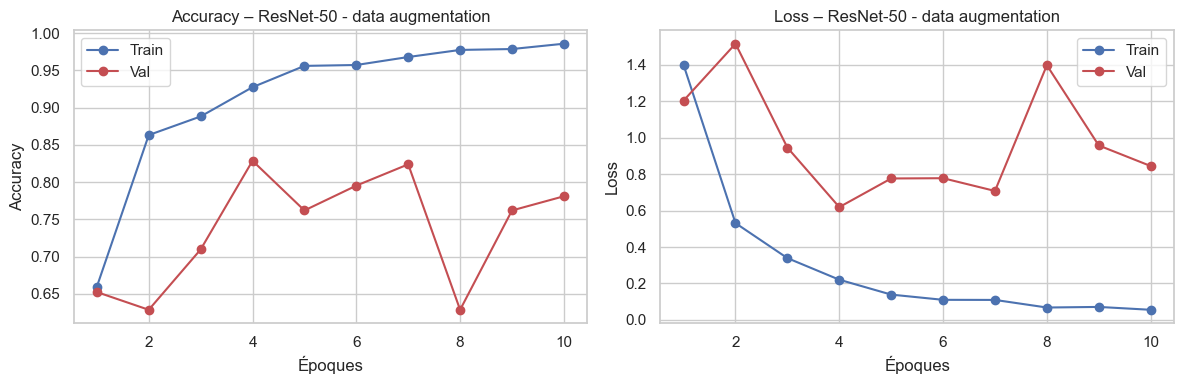

In [53]:
plot_training_curves(history_resnet50, title="ResNet-50 - data augmentation")

## 🧬 Comparaison ResNet50 – Dense(512) vs Dense(1024)

Deux architectures ont été testées avec ResNet50 :

- `model3` : couche Dense de **512 neurones**
- `model4` : couche Dense de **1024 neurones**

Toutes deux utilisent un `Dropout(0.5)` pour limiter le surapprentissage.

### 📊 Résultats observés :

- Le modèle avec 512 neurones (**model3**) est **plus stable**, avec un bon compromis entre performance et généralisation.
- Le modèle avec 1024 neurones (**model4**) présente **de fortes fluctuations** dans la loss et l’accuracy validation → risque de **surapprentissage accru**.
- **Recommandation :** conserver l’architecture à 512 neurones pour ResNet50 dans notre cas.



# Analyse complete entre VGG16 et ResNet50

## 🤖 Comparaison des modèles CNN : VGG16 vs ResNet50

| Critère                        | VGG16                                 | ResNet50                                  |
|-------------------------------|----------------------------------------|-------------------------------------------|
| Profondeur                    | 16 couches                             | 50 couches                                |
| Taille du modèle              | ~138M paramètres                       | ~25M paramètres                           |
| Architecture                  | Linéaire (empilement)                  | Résiduelle (skip connections)             |
| Vitesse                       | Plus rapide à entraîner                | Plus lent                                 |
| Surapprentissage              | Modéré avec Dense(512)                 | Marqué avec Dense(1024)                   |
| Validation accuracy max       | ~74% (stable)                          | ~84% (instable)                           |
| Recommandation                | ✅ Meilleur compromis stabilité/perf.  | ⚠️ Plus complexe à régulariser            |

### ✅ Conclusion :
> Dans le cadre de notre projet, **VGG16 avec Dense(512) et Dropout(0.5)** offre le **meilleur compromis entre performance, stabilité et vitesse d'entraînement**.  
> ResNet50 reste intéressant, mais nécessite **plus de régularisation** pour éviter l'overfitting.

# Suite dans le notebook : products_from_api